In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import unicodedata
import time
import os
import csv
from scipy import stats
from scipy.signal import detrend
from tqdm.auto import tqdm

c:\Users\user\Desktop\nlpproject\projectfolder2\king_lo\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Φόρτωση preprocessed data από phase1 (χωρίς να ξανατρέξουμε το cleaning)
csv.field_size_limit(10**7)

df = pd.read_csv(
    r"..\data\df_preprocessed.csv",
    encoding="utf-8-sig",
    engine="python"
)

bonds_df = pd.read_excel(r"..\data\Greece_Germany_Bond_Spread_2010_2026.xlsx")
hkks_df  = pd.read_excel(r"..\data\HKKS_Greece_Policy_Uncertainty_Data.xlsx")

print(f"Articles: {len(df):,}")
print(f"Bond weeks: {len(bonds_df):,}")
print(f"HKKS months: {len(hkks_df):,}")
print(f"\nColumns: {list(df.columns)}")

Articles: 874,137
Bond weeks: 844
HKKS months: 333

Columns: ['word_count', 'date', 'heading_type', 'article_title', 'content', 'char_count', 'hit_UNCERTAINTY', 'hit_ECONOMY', 'hit_POLICY', 'cat_hits']


In [3]:
# Hardouvelis et al. (2018) — exact keywords με full words αντί για stems
epu_terms_v2 = {
    "UNCERTAINTY": [
        "αβεβαιότητα", "αβεβαιότητας", "αβεβαιότητές",
        "ασάφεια", "ασάφειας", "αμφιβολία", "αμφιβολίας",
        "ανησυχία", "ανησυχίας", "αστάθεια", "αστάθειας",
        "κίνδυνος", "κινδύνου", "κινδύνων",
        "απρόβλεπτο", "απειλή", "απειλής", "ευάλωτο"
    ],
    "ECONOMY": [
        "οικονομία", "οικονομίας", "οικονομίες",
        "ανάπτυξη", "ανάπτυξης", "ύφεση", "ύφεσης",
        "ανεργία", "ανεργίας", "απασχόληση", "απασχόλησης",
        "επένδυση", "επένδυσης", "επενδύσεις",
        "εξαγωγές", "εξαγωγών", "εισαγωγές", "εισαγωγών",
        "εμπόριο", "εμπορίου", "ΑΕΠ",
        "μισθοί", "μισθών", "εισόδημα", "εισοδήματος",
        "παραγωγή", "παραγωγής"
    ],
    "POLICY": [
        "Βουλή", "Βουλής", "νομοθεσία", "νομοθεσίας",
        "κυβέρνηση", "κυβέρνησης", "κυβερνήσεις",
        "Τράπεζα της Ελλάδος", "Τράπεζας της Ελλάδος",
        "κεντρική τράπεζα", "κεντρικής τράπεζας",
        "μεταρρύθμιση", "μεταρρύθμισης", "μεταρρυθμίσεις",
        "διαρθρωτικές αλλαγές", "νόμος", "νόμου", "νόμων",
        "υπουργός", "υπουργού", "υπουργοί",
        "πρωθυπουργός", "πρωθυπουργού",
        "Μαξίμου", "έλλειμμα", "ελλείμματος",
        "απορρύθμιση", "κανονιστικό πλαίσιο",
        "Επιτροπή Κεφαλαιαγοράς", "Επιτροπή Ανταγωνισμού",
        "Συμβούλιο Επικρατείας"
    ]
}

for cat, terms in epu_terms_v2.items():
    print(f"{cat}: {len(terms)} keywords")

UNCERTAINTY: 18 keywords
ECONOMY: 27 keywords
POLICY: 31 keywords


In [4]:
# Compiled regex με word boundaries για exact matching
_combining = re.compile(r"[\u0300-\u036f]")

def strip_accents_fast(s):
    return _combining.sub("", unicodedata.normalize("NFD", s))

# Normalize keywords και patterns
epu_terms_v2_norm = {
    cat: [strip_accents_fast(kw).lower() for kw in keywords]
    for cat, keywords in epu_terms_v2.items()
}

cat_patterns_v2 = {
    cat: re.compile(r"\b(" + "|".join(re.escape(kw) for kw in keywords) + r")\b")
    for cat, keywords in epu_terms_v2_norm.items()
}

cat_list = list(epu_terms_v2.keys())
for cat in cat_list:
    df[f"hit2_{cat}"] = False

CHUNK = 100_000
n  = len(df)
t0 = time.time()

print(f"Processing {n:,} articles in chunks of {CHUNK:,}...\n")

for start in range(0, n, CHUNK):
    end        = min(start + CHUNK, n)
    chunk_norm = (
        df["content"].iloc[start:end]
        .fillna("")
        .str.lower()
        .apply(strip_accents_fast)
    )
    for cat, pattern in cat_patterns_v2.items():
        df.loc[df.index[start:end], f"hit2_{cat}"] = (
            chunk_norm.str.contains(pattern, regex=True).values
        )
    elapsed = time.time() - t0
    eta     = (elapsed / end) * (n - end)
    print(f"  {end:>9,} / {n:,}  ({end/n*100:.1f}%)  elapsed: {elapsed:.0f}s  ETA: {eta:.0f}s")

hit_cols_v2    = [f"hit2_{cat}" for cat in cat_list]
df["cat_hits2"] = df[hit_cols_v2].sum(axis=1)

print(f"\nDone in {time.time()-t0:.0f}s")
print(f"\nEPU corpus v2: {(df['hit2_UNCERTAINTY'] & df['hit2_ECONOMY'] & df['hit2_POLICY']).sum():,} articles")
print(f"EPU corpus v1: {(df['hit_UNCERTAINTY'] & df['hit_ECONOMY'] & df['hit_POLICY']).sum():,} articles")

Processing 874,137 articles in chunks of 100,000...



C:\Users\user\AppData\Local\Temp\ipykernel_2380\3865689116.py:38: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  chunk_norm.str.contains(pattern, regex=True).values
C:\Users\user\AppData\Local\Temp\ipykernel_2380\3865689116.py:38: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  chunk_norm.str.contains(pattern, regex=True).values
C:\Users\user\AppData\Local\Temp\ipykernel_2380\3865689116.py:38: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  chunk_norm.str.contains(pattern, regex=True).values


    100,000 / 874,137  (11.4%)  elapsed: 41s  ETA: 317s


C:\Users\user\AppData\Local\Temp\ipykernel_2380\3865689116.py:38: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  chunk_norm.str.contains(pattern, regex=True).values
C:\Users\user\AppData\Local\Temp\ipykernel_2380\3865689116.py:38: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  chunk_norm.str.contains(pattern, regex=True).values
C:\Users\user\AppData\Local\Temp\ipykernel_2380\3865689116.py:38: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  chunk_norm.str.contains(pattern, regex=True).values


    200,000 / 874,137  (22.9%)  elapsed: 75s  ETA: 253s


...

    700,000 / 874,137  (80.1%)  elapsed: 231s  ETA: 57s


C:\Users\user\AppData\Local\Temp\ipykernel_2380\3865689116.py:38: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  chunk_norm.str.contains(pattern, regex=True).values
C:\Users\user\AppData\Local\Temp\ipykernel_2380\3865689116.py:38: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  chunk_norm.str.contains(pattern, regex=True).values
C:\Users\user\AppData\Local\Temp\ipykernel_2380\3865689116.py:38: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  chunk_norm.str.contains(pattern, regex=True).values


    800,000 / 874,137  (91.5%)  elapsed: 261s  ETA: 24s


C:\Users\user\AppData\Local\Temp\ipykernel_2380\3865689116.py:38: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  chunk_norm.str.contains(pattern, regex=True).values
C:\Users\user\AppData\Local\Temp\ipykernel_2380\3865689116.py:38: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  chunk_norm.str.contains(pattern, regex=True).values
C:\Users\user\AppData\Local\Temp\ipykernel_2380\3865689116.py:38: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  chunk_norm.str.contains(pattern, regex=True).values


    874,137 / 874,137  (100.0%)  elapsed: 280s  ETA: 0s

Done in 280s

EPU corpus v2: 35,167 articles
EPU corpus v1: 147,710 articles


In [5]:
# Δημιουργία df_epu_v2
df_epu_v2 = df[
    df["hit2_UNCERTAINTY"] & df["hit2_ECONOMY"] & df["hit2_POLICY"]
].copy().reset_index(drop=True)

print(f"EPU corpus v2: {len(df_epu_v2):,} articles")

# Weekly aggregation
df_epu_v2["week"] = pd.to_datetime(df_epu_v2["date"], format="%m/%d/%Y").dt.to_period("W")

total_per_week = (
    df.assign(week=pd.to_datetime(df["date"], format="%m/%d/%Y").dt.to_period("W"))
    .groupby("week")
    .size()
    .rename("total_articles")
    .reset_index()
)

epu_per_week_v2 = (
    df_epu_v2.groupby("week")
    .agg(epu_articles=("date", "count"))
    .reset_index()
)

weekly_v2 = epu_per_week_v2.merge(total_per_week, on="week")
weekly_v2["epu_rate"] = weekly_v2["epu_articles"] / weekly_v2["total_articles"]

# Rolling 12-month (52-week) normalization — Hardouvelis methodology
weekly_v2 = weekly_v2.sort_values("week").reset_index(drop=True)
weekly_v2["rolling_mean"] = weekly_v2["epu_rate"].rolling(52, min_periods=26).mean()
weekly_v2["epu_index_v2"] = weekly_v2["epu_rate"] / weekly_v2["rolling_mean"] * 100
weekly_v2["week_dt"] = weekly_v2["week"].dt.to_timestamp()

# Drop NaN από rolling window
weekly_v2 = weekly_v2.dropna(subset=["epu_index_v2"]).reset_index(drop=True)

print(f"Weeks: {len(weekly_v2)} ({weekly_v2['week'].min()} – {weekly_v2['week'].max()})")
weekly_v2[["week", "epu_articles", "total_articles", "epu_rate", "epu_index_v2"]].tail(12)

EPU corpus v2: 35,167 articles
Weeks: 819 (2010-06-21/2010-06-27 – 2026-02-23/2026-03-01)


,week,epu_articles,total_articles,epu_rate,epu_index_v2
807,2025-12-08/2025-12-14,68,1067,0.063730,113.541377
808,2025-12-15/2025-12-21,64,1029,0.062196,110.037557
809,2025-12-22/2025-12-28,30,739,0.040595,71.716239
810,2025-12-29/2026-01-04,33,715,0.046154,81.886020
811,2026-01-05/2026-01-11,48,859,0.055879,98.826303
812,2026-01-12/2026-01-18,54,1057,0.051088,90.575590
813,2026-01-19/2026-01-25,68,1034,0.065764,115.791765
814,2026-01-26/2026-02-01,67,1076,0.062268,108.860471
815,2026-02-02/2026-02-08,56,1118,0.050089,87.757855
816,2026-02-09/2026-02-15,56,1030,0.054369,95.387344


In [6]:
# Bond spread preparation
bonds_df["week"] = pd.to_datetime(bonds_df["Date"], format="%m/%d/%Y").dt.to_period("W")
bonds_weekly = bonds_df[["week", "Spread"]].copy()

# Merge
merged_v2 = weekly_v2.merge(bonds_weekly, on="week", how="inner")
merged_v2 = merged_v2.iloc[:-1].reset_index(drop=True)  # Drop incomplete last week

print(f"Merged: {len(merged_v2)} weeks ({merged_v2['week'].min()} – {merged_v2['week'].max()})")

# Correlation
epu_d    = detrend(merged_v2["epu_index_v2"].values)
spread_d = detrend(merged_v2["Spread"].values)

pr, pp = stats.pearsonr(epu_d, spread_d)
sr, sp = stats.spearmanr(epu_d, spread_d)

print(f"\nFull sample (detrended):")
print(f"Pearson r:  {pr:.4f}  (p={pp:.4f})")
print(f"Spearman r: {sr:.4f}  (p={sp:.4f})")

# Subperiods
merged_v2["week_dt"] = merged_v2["week"].dt.to_timestamp()
crisis_v2 = merged_v2[merged_v2["week_dt"] <= "2015-12-31"]
post_v2   = merged_v2[merged_v2["week_dt"] >  "2015-12-31"]

print(f"\nCrisis: {len(crisis_v2)} weeks | Post-crisis: {len(post_v2)} weeks")

for label, subset in [("Crisis 2010-2015", crisis_v2), ("Post-crisis 2016-2026", post_v2)]:
    epu_d    = detrend(subset["epu_index_v2"].values)
    spread_d = detrend(subset["Spread"].values)
    pr, pp   = stats.pearsonr(epu_d, spread_d)
    sr, sp   = stats.spearmanr(epu_d, spread_d)
    print(f"\n--- {label} ---")
    print(f"Pearson r:  {pr:.4f}  (p={pp:.4f})")
    print(f"Spearman r: {sr:.4f}  (p={sp:.4f})")

Merged: 818 weeks (2010-06-21/2010-06-27 – 2026-02-16/2026-02-22)

Full sample (detrended):
Pearson r:  0.0349  (p=0.3183)
Spearman r: 0.1118  (p=0.0014)

Crisis: 289 weeks | Post-crisis: 529 weeks

--- Crisis 2010-2015 ---
Pearson r:  0.0421  (p=0.4755)
Spearman r: 0.1118  (p=0.0576)

--- Post-crisis 2016-2026 ---
Pearson r:  0.0920  (p=0.0343)
Spearman r: 0.1253  (p=0.0039)


In [7]:
# v3 — Στοχευμένα stems + rolling normalization
epu_terms_v3 = {
    "UNCERTAINTY": [
        "αβεβαιοτητ",   # αβεβαιότητα και όλες οι πτώσεις
        "αβεβαι",       # αβέβαιος, αβέβαιο
        "ανησυχ",       # ανησυχία, ανησυχεί
        "αστaθ",        # αστάθεια
        "κινδυν",       # κίνδυνος, κινδύνου
        "απροβλεπτ",    # απρόβλεπτο
        "αμφιβολ",      # αμφιβολία
    ],
    "ECONOMY": [
        "οικονομ",      # οικονομία, οικονομικός
        "αναπτυξ",      # ανάπτυξη
        "υφεσ",         # ύφεση
        "ανεργ",        # ανεργία
        "επενδυσ",      # επένδυση, επενδύσεις
        "εξαγωγ",       # εξαγωγές
        "εισαγωγ",      # εισαγωγές
        "αεπ",          # ΑΕΠ
        "μισθ",         # μισθοί
        "εισοδημ",      # εισόδημα
    ],
    "POLICY": [
        "κυβερνησ",     # κυβέρνηση
        "βουλ",         # Βουλή — αλλά μόνο με άλλα EPU terms
        "υπουργ",       # υπουργός
        "πρωθυπουργ",   # πρωθυπουργός
        "νομοθεσ",      # νομοθεσία
        "μεταρρυθμ",    # μεταρρύθμιση
        "ελλειμμ",      # έλλειμμα
        "τραπεζ ελλαδ", # Τράπεζα Ελλάδος
        "μαξιμ",        # Μαξίμου
        "κανονιστικ",   # κανονιστικό πλαίσιο
    ]
}

for cat, terms in epu_terms_v3.items():
    print(f"{cat}: {len(terms)} keywords")

UNCERTAINTY: 7 keywords
ECONOMY: 10 keywords
POLICY: 10 keywords


In [8]:
# v3 Keyword Matching
cat_patterns_v3 = {
    cat: re.compile("|".join(re.escape(kw) for kw in keywords))
    for cat, keywords in epu_terms_v3.items()
}

for cat in cat_list:
    df[f"hit3_{cat}"] = False

CHUNK = 100_000
n  = len(df)
t0 = time.time()

print(f"Processing {n:,} articles in chunks of {CHUNK:,}...\n")

for start in range(0, n, CHUNK):
    end        = min(start + CHUNK, n)
    chunk_norm = (
        df["content"].iloc[start:end]
        .fillna("")
        .str.lower()
        .apply(strip_accents_fast)
    )
    for cat, pattern in cat_patterns_v3.items():
        df.loc[df.index[start:end], f"hit3_{cat}"] = (
            chunk_norm.str.contains(pattern, regex=True).values
        )
    elapsed = time.time() - t0
    eta     = (elapsed / end) * (n - end)
    print(f"  {end:>9,} / {n:,}  ({end/n*100:.1f}%)  elapsed: {elapsed:.0f}s  ETA: {eta:.0f}s")

df_epu_v3 = df[
    df["hit3_UNCERTAINTY"] & df["hit3_ECONOMY"] & df["hit3_POLICY"]
].copy().reset_index(drop=True)

print(f"\nEPU corpus v1: {(df['hit_UNCERTAINTY']  & df['hit_ECONOMY']  & df['hit_POLICY']).sum():,} articles")
print(f"EPU corpus v2: {(df['hit2_UNCERTAINTY'] & df['hit2_ECONOMY'] & df['hit2_POLICY']).sum():,} articles")
print(f"EPU corpus v3: {len(df_epu_v3):,} articles ({len(df_epu_v3)/len(df)*100:.1f}%)")

Processing 874,137 articles in chunks of 100,000...

    100,000 / 874,137  (11.4%)  elapsed: 28s  ETA: 215s
    200,000 / 874,137  (22.9%)  elapsed: 51s  ETA: 173s
    300,000 / 874,137  (34.3%)  elapsed: 72s  ETA: 138s
    400,000 / 874,137  (45.8%)  elapsed: 91s  ETA: 108s
    500,000 / 874,137  (57.2%)  elapsed: 114s  ETA: 85s
    600,000 / 874,137  (68.6%)  elapsed: 138s  ETA: 63s
    700,000 / 874,137  (80.1%)  elapsed: 161s  ETA: 40s
    800,000 / 874,137  (91.5%)  elapsed: 182s  ETA: 17s
    874,137 / 874,137  (100.0%)  elapsed: 195s  ETA: 0s

EPU corpus v1: 147,710 articles
EPU corpus v2: 35,167 articles
EPU corpus v3: 93,965 articles (10.7%)


In [9]:
# Weekly aggregation v3 με rolling normalization
df_epu_v3["week"] = pd.to_datetime(df_epu_v3["date"], format="%m/%d/%Y").dt.to_period("W")

epu_per_week_v3 = (
    df_epu_v3.groupby("week")
    .agg(epu_articles=("date", "count"))
    .reset_index()
)

weekly_v3 = epu_per_week_v3.merge(total_per_week, on="week")
weekly_v3["epu_rate"]    = weekly_v3["epu_articles"] / weekly_v3["total_articles"]
weekly_v3                = weekly_v3.sort_values("week").reset_index(drop=True)
weekly_v3["rolling_mean"] = weekly_v3["epu_rate"].rolling(52, min_periods=26).mean()
weekly_v3["epu_index_v3"] = weekly_v3["epu_rate"] / weekly_v3["rolling_mean"] * 100
weekly_v3["week_dt"]      = weekly_v3["week"].dt.to_timestamp()
weekly_v3                 = weekly_v3.dropna(subset=["epu_index_v3"]).reset_index(drop=True)

# Merge με bond spread
merged_v3 = weekly_v3.merge(bonds_weekly, on="week", how="inner")
merged_v3 = merged_v3.iloc[:-1].reset_index(drop=True)

print(f"Merged: {len(merged_v3)} weeks ({merged_v3['week'].min()} – {merged_v3['week'].max()})")

# Full sample correlation
epu_d    = detrend(merged_v3["epu_index_v3"].values)
spread_d = detrend(merged_v3["Spread"].values)

pr, pp = stats.pearsonr(epu_d, spread_d)
sr, sp = stats.spearmanr(epu_d, spread_d)
print(f"\nFull sample (detrended):")
print(f"Pearson r:  {pr:.4f}  (p={pp:.4f})")
print(f"Spearman r: {sr:.4f}  (p={sp:.4f})")

# Subperiods
merged_v3["week_dt"] = merged_v3["week"].dt.to_timestamp()
crisis_v3 = merged_v3[merged_v3["week_dt"] <= "2015-12-31"]
post_v3   = merged_v3[merged_v3["week_dt"] >  "2015-12-31"]

print(f"\nCrisis: {len(crisis_v3)} weeks | Post-crisis: {len(post_v3)} weeks")

for label, subset in [("Crisis 2010-2015", crisis_v3), ("Post-crisis 2016-2026", post_v3)]:
    epu_d    = detrend(subset["epu_index_v3"].values)
    spread_d = detrend(subset["Spread"].values)
    pr, pp   = stats.pearsonr(epu_d, spread_d)
    sr, sp   = stats.spearmanr(epu_d, spread_d)
    print(f"\n--- {label} ---")
    print(f"Pearson r:  {pr:.4f}  (p={pp:.4f})")
    print(f"Spearman r: {sr:.4f}  (p={sp:.4f})")
    

Merged: 818 weeks (2010-06-21/2010-06-27 – 2026-02-16/2026-02-22)

Full sample (detrended):
Pearson r:  0.0633  (p=0.0705)
Spearman r: 0.1357  (p=0.0001)

Crisis: 289 weeks | Post-crisis: 529 weeks

--- Crisis 2010-2015 ---
Pearson r:  0.0988  (p=0.0938)
Spearman r: 0.1792  (p=0.0022)

--- Post-crisis 2016-2026 ---
Pearson r:  0.0575  (p=0.1870)
Spearman r: 0.1024  (p=0.0184)


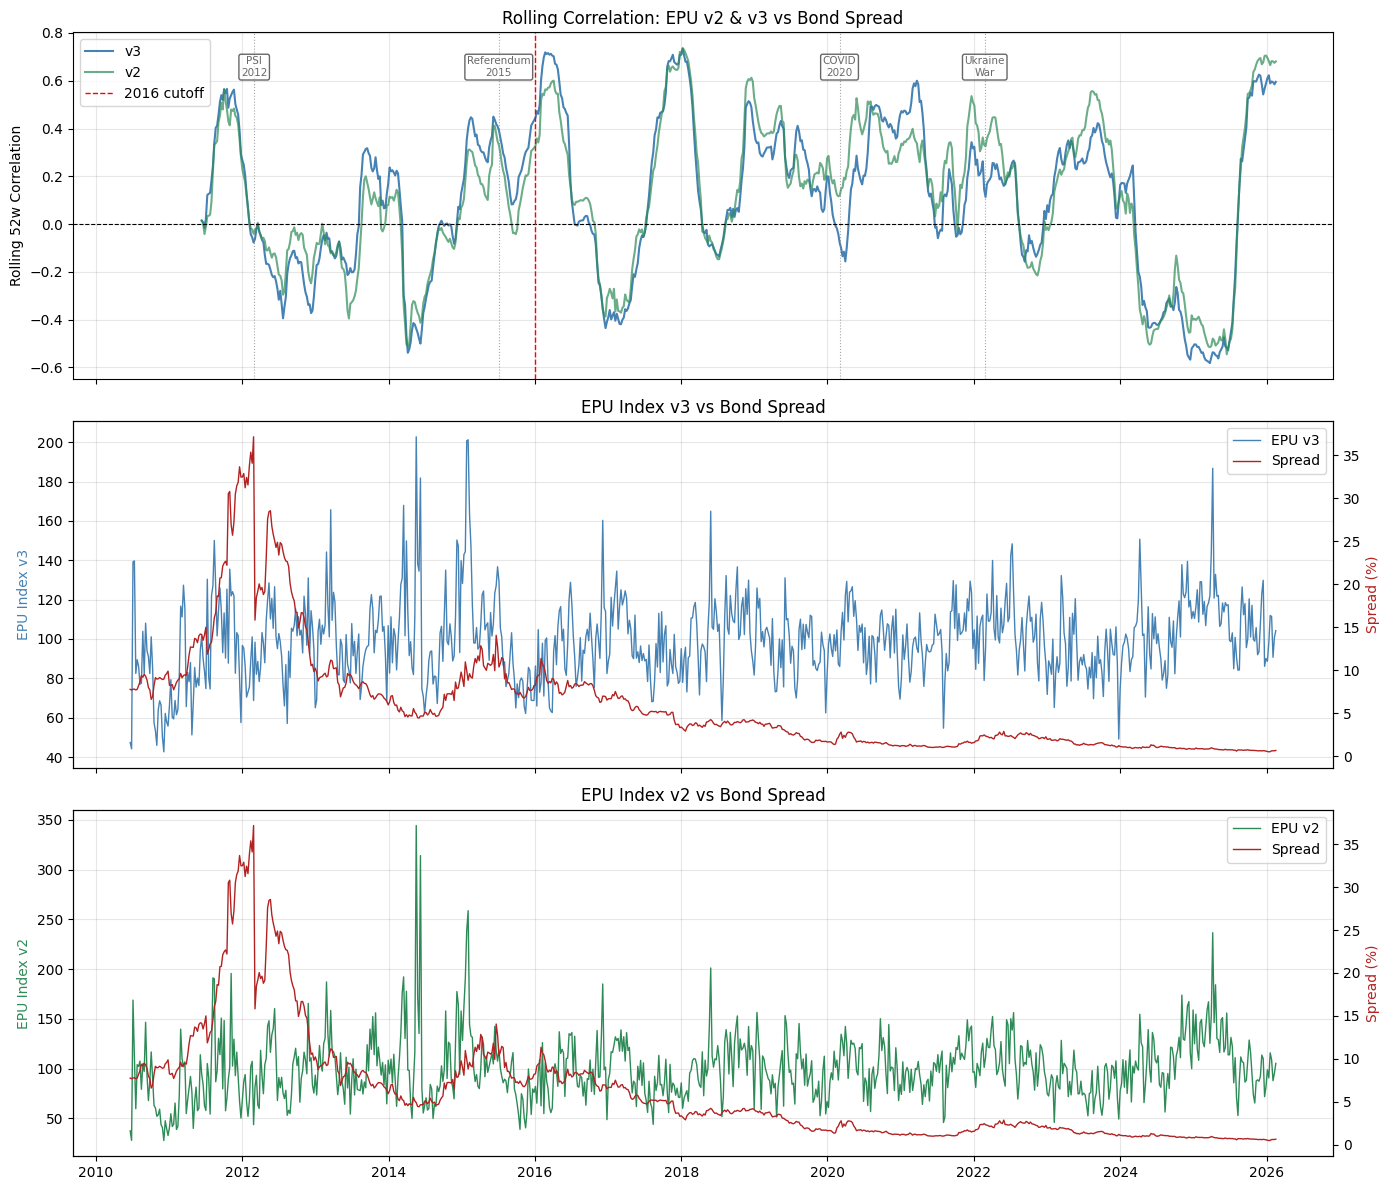

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

versions = [
    (merged_v3, "epu_index_v3", "v3 — Στοχευμένα stems + rolling norm", "steelblue"),
    (merged_v2, "epu_index_v2", "v2 — Full words + rolling norm", "seagreen"),
]

# Rolling correlations
merged_v3_s = merged_v3.sort_values("week_dt").reset_index(drop=True)
merged_v2_s = merged_v2.sort_values("week_dt").reset_index(drop=True)

rc_v3 = merged_v3_s["epu_index_v3"].rolling(52).corr(merged_v3_s["Spread"])
rc_v2 = merged_v2_s["epu_index_v2"].rolling(52).corr(merged_v2_s["Spread"])

events = {
    "PSI\n2012":        "2012-03-01",
    "Referendum\n2015": "2015-07-05",
    "COVID\n2020":      "2020-03-01",
    "Ukraine\nWar":     "2022-02-24",
}

# Panel 1: Rolling correlation v3
axes[0].plot(merged_v3_s["week_dt"], rc_v3, color="steelblue", linewidth=1.5, label="v3")
axes[0].plot(merged_v2_s["week_dt"], rc_v2, color="seagreen",  linewidth=1.5, label="v2", alpha=0.7)
axes[0].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[0].axvline(pd.Timestamp("2015-12-31"), color="red", linewidth=1, linestyle="--", label="2016 cutoff")
for label, date in events.items():
    axes[0].axvline(pd.Timestamp(date), color="gray", linewidth=0.8, linestyle=":", alpha=0.7)
    axes[0].text(pd.Timestamp(date), 0.62, label, fontsize=7.5, ha="center",
                 color="dimgray", bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.6))
axes[0].set_ylabel("Rolling 52w Correlation")
axes[0].set_title("Rolling Correlation: EPU v2 & v3 vs Bond Spread")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Panel 2: EPU v3 vs Spread
ax2t = axes[1].twinx()
axes[1].plot(merged_v3_s["week_dt"], merged_v3_s["epu_index_v3"], color="steelblue", linewidth=1, label="EPU v3")
ax2t.plot(merged_v3_s["week_dt"], merged_v3_s["Spread"], color="firebrick", linewidth=1, label="Spread")
axes[1].set_ylabel("EPU Index v3", color="steelblue")
ax2t.set_ylabel("Spread (%)", color="firebrick")
axes[1].set_title("EPU Index v3 vs Bond Spread")
lines1, labels1 = axes[1].get_legend_handles_labels()
lines2, labels2 = ax2t.get_legend_handles_labels()
axes[1].legend(lines1 + lines2, labels1 + labels2, loc="upper right")
axes[1].grid(alpha=0.3)

# Panel 3: EPU v2 vs Spread
ax3t = axes[2].twinx()
axes[2].plot(merged_v2_s["week_dt"], merged_v2_s["epu_index_v2"], color="seagreen", linewidth=1, label="EPU v2")
ax3t.plot(merged_v2_s["week_dt"], merged_v2_s["Spread"], color="firebrick", linewidth=1, label="Spread")
axes[2].set_ylabel("EPU Index v2", color="seagreen")
ax3t.set_ylabel("Spread (%)", color="firebrick")
axes[2].set_title("EPU Index v2 vs Bond Spread")
lines1, labels1 = axes[2].get_legend_handles_labels()
lines2, labels2 = ax3t.get_legend_handles_labels()
axes[2].legend(lines1 + lines2, labels1 + labels2, loc="upper right")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("epu_v2_v3_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

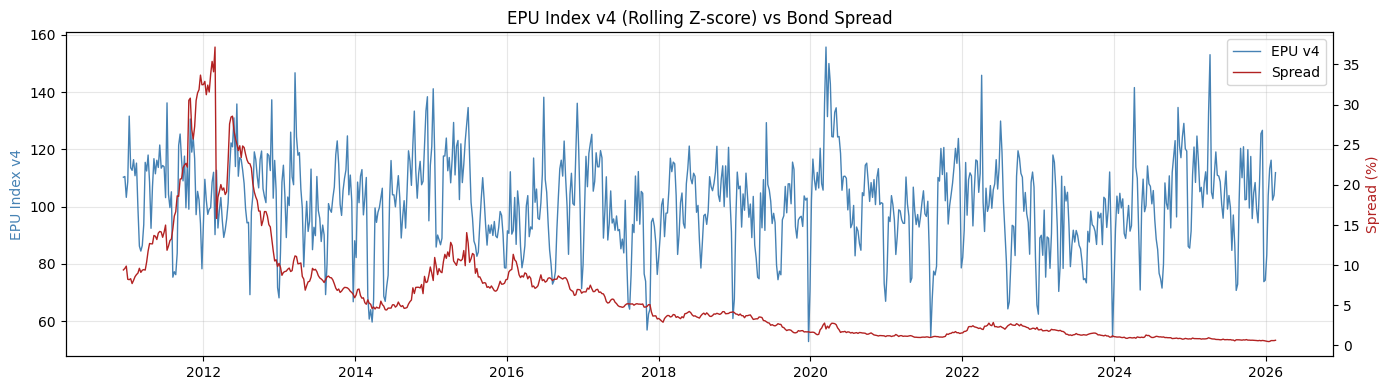

Pearson r:  0.1064  (p=0.0027)
Spearman r: 0.1311  (p=0.0002)


In [11]:
# v4 — Rolling Z-score normalization
weekly_v3 = weekly_v3.sort_values("week").reset_index(drop=True)

rolling_mean = weekly_v3["epu_articles"].rolling(52, min_periods=26).mean()
rolling_std  = weekly_v3["epu_articles"].rolling(52, min_periods=26).std()

weekly_v3["epu_index_v4"] = (
    (weekly_v3["epu_articles"] - rolling_mean) / rolling_std
) * 15 + 100  # scale to mean=100, std=15

weekly_v3["week_dt"] = weekly_v3["week"].dt.to_timestamp()
weekly_v3_clean = weekly_v3.dropna(subset=["epu_index_v4"]).reset_index(drop=True)

# Quick plot να δούμε αν έχει νόημα
merged_v4 = weekly_v3_clean.merge(bonds_weekly, on="week", how="inner").iloc[:-1]
merged_v4["week_dt"] = merged_v4["week"].dt.to_timestamp()

fig, ax1 = plt.subplots(figsize=(14, 4))
ax2 = ax1.twinx()
ax1.plot(merged_v4["week_dt"], merged_v4["epu_index_v4"], color="steelblue", linewidth=1, label="EPU v4")
ax2.plot(merged_v4["week_dt"], merged_v4["Spread"], color="firebrick", linewidth=1, label="Spread")
ax1.set_ylabel("EPU Index v4", color="steelblue")
ax2.set_ylabel("Spread (%)", color="firebrick")
ax1.set_title("EPU Index v4 (Rolling Z-score) vs Bond Spread")
ax1.grid(alpha=0.3)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)
plt.tight_layout()
plt.savefig("epu_v4.png", dpi=150, bbox_inches="tight")
plt.show()

# Correlation
epu_d    = detrend(merged_v4["epu_index_v4"].values)
spread_d = detrend(merged_v4["Spread"].values)
pr, pp   = stats.pearsonr(epu_d, spread_d)
sr, sp   = stats.spearmanr(epu_d, spread_d)
print(f"Pearson r:  {pr:.4f}  (p={pp:.4f})")
print(f"Spearman r: {sr:.4f}  (p={sp:.4f})")

In [12]:
merged_v4["week_dt"] = merged_v4["week"].dt.to_timestamp()
crisis_v4   = merged_v4[merged_v4["week_dt"] <= "2015-12-31"]
post_v4     = merged_v4[merged_v4["week_dt"] >  "2015-12-31"]
covid_v4    = merged_v4[(merged_v4["week_dt"] >= "2019-01-01") & 
                         (merged_v4["week_dt"] <= "2021-12-31")]

print(f"Crisis: {len(crisis_v4)} | Post: {len(post_v4)} | COVID window: {len(covid_v4)}\n")

for label, subset in [
    ("Crisis 2010-2015",    crisis_v4),
    ("Post-crisis 2016-26", post_v4),
    ("COVID 2019-2021",     covid_v4),
]:
    if len(subset) < 30:
        continue
    epu_d    = detrend(subset["epu_index_v4"].values)
    spread_d = detrend(subset["Spread"].values)
    pr, pp   = stats.pearsonr(epu_d, spread_d)
    sr, sp   = stats.spearmanr(epu_d, spread_d)
    print(f"--- {label} ---")
    print(f"Pearson r:  {pr:.4f}  (p={pp:.4f})")
    print(f"Spearman r: {sr:.4f}  (p={sp:.4f})\n")

Crisis: 264 | Post: 529 | COVID window: 156

--- Crisis 2010-2015 ---
Pearson r:  0.1122  (p=0.0687)
Spearman r: 0.1485  (p=0.0158)

--- Post-crisis 2016-26 ---
Pearson r:  0.0264  (p=0.5440)
Spearman r: 0.0570  (p=0.1904)

--- COVID 2019-2021 ---
Pearson r:  0.1658  (p=0.0386)
Spearman r: 0.1170  (p=0.1457)



In [13]:
# Monthly aggregation για σύγκριση με Hardouvelis
weekly_v3_clean["month"] = weekly_v3_clean["week"].dt.to_timestamp().dt.to_period("M")

monthly_v4 = (
    weekly_v3_clean.groupby("month")
    .agg(epu_index_v4=("epu_index_v4", "mean"))
    .reset_index()
)

# Hardouvelis data prep
hkks_df["month"] = pd.to_datetime(hkks_df["Date"]).dt.to_period("M")

# Merge
comparison = monthly_v4.merge(hkks_df[["month", "EPU"]], on="month", how="inner")
comparison = comparison.rename(columns={"EPU": "EPU_hardouvelis", "epu_index_v4": "EPU_ours"})

print(f"Common months: {len(comparison)}")
print(f"Period: {comparison['month'].min()} – {comparison['month'].max()}\n")

# Correlation
pr, pp = stats.pearsonr(comparison["EPU_ours"], comparison["EPU_hardouvelis"])
sr, sp = stats.spearmanr(comparison["EPU_ours"], comparison["EPU_hardouvelis"])
print(f"Pearson r:  {pr:.4f}  (p={pp:.4f})")
print(f"Spearman r: {sr:.4f}  (p={sp:.4f})")

Common months: 178
Period: 2010-12 – 2025-09

Pearson r:  0.3504  (p=0.0000)
Spearman r: 0.3270  (p=0.0000)


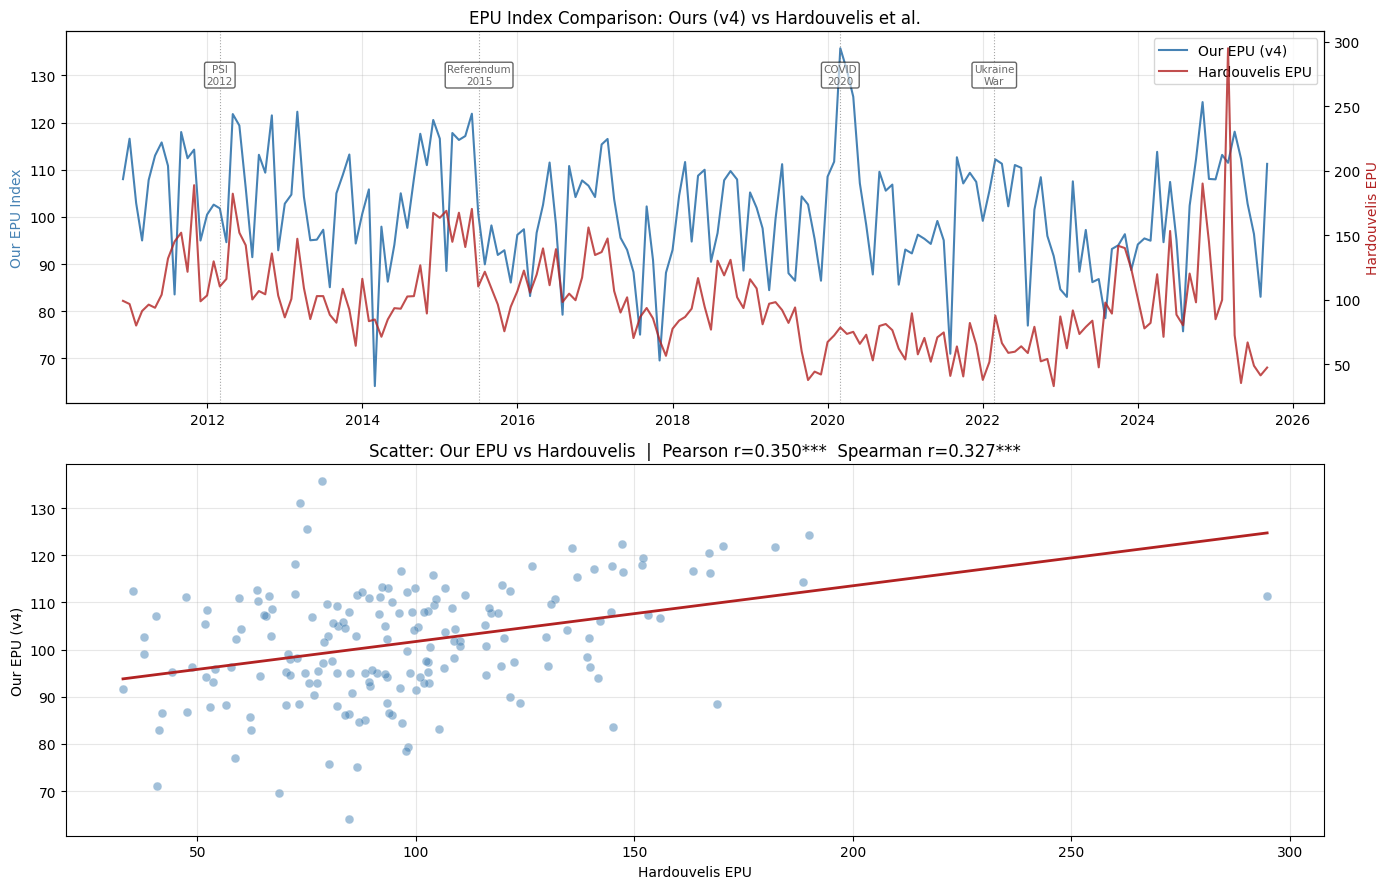

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

month_dt = comparison["month"].dt.to_timestamp()

# Panel 1 — Time series comparison
ax1 = axes[0]
ax1b = ax1.twinx()
ax1.plot(month_dt, comparison["EPU_ours"],        color="steelblue", linewidth=1.5, label="Our EPU (v4)")
ax1b.plot(month_dt, comparison["EPU_hardouvelis"], color="firebrick",  linewidth=1.5, label="Hardouvelis EPU", alpha=0.8)
ax1.set_ylabel("Our EPU Index", color="steelblue")
ax1b.set_ylabel("Hardouvelis EPU", color="firebrick")
ax1.set_title("EPU Index Comparison: Ours (v4) vs Hardouvelis et al.")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1b.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")
ax1.grid(alpha=0.3)

events = {
    "PSI\n2012": "2012-03-01", "Referendum\n2015": "2015-07-05",
    "COVID\n2020": "2020-03-01", "Ukraine\nWar": "2022-02-24",
}
for label, date in events.items():
    ax1.axvline(pd.Timestamp(date), color="gray", linewidth=0.8, linestyle=":", alpha=0.7)
    ax1.text(pd.Timestamp(date), ax1.get_ylim()[1]*0.92, label,
             fontsize=7.5, ha="center", color="dimgray",
             bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.6))

# Panel 2 — Scatter plot
ax2 = axes[1]
ax2.scatter(comparison["EPU_hardouvelis"], comparison["EPU_ours"],
            alpha=0.5, color="steelblue", edgecolors="white", linewidth=0.3, s=40)

# Regression line
m, b = np.polyfit(comparison["EPU_hardouvelis"], comparison["EPU_ours"], 1)
x_line = np.linspace(comparison["EPU_hardouvelis"].min(), comparison["EPU_hardouvelis"].max(), 100)
ax2.plot(x_line, m * x_line + b, color="firebrick", linewidth=2)

ax2.set_xlabel("Hardouvelis EPU")
ax2.set_ylabel("Our EPU (v4)")
ax2.set_title(f"Scatter: Our EPU vs Hardouvelis  |  Pearson r=0.350***  Spearman r=0.327***")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("epu_v4_hardouvelis_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [15]:
print("=" * 65)
print("PHASE 2 — EPU INDEX v4 RESULTS SUMMARY")
print("=" * 65)

print(f"""
DATASET
  Articles processed : 874,137
  EPU corpus (v3 kw) : 93,965  (10.7%)
  Weekly obs         : 818 weeks (2010-W25 – 2026-W07)
  Monthly obs        : 178 months (2010-12 – 2025-09)

METHODOLOGY
  Keywords           : Hardouvelis-inspired stems (7+10+10)
  Normalization      : Rolling 52-week Z-score → mean=100, std=15
  Matching           : All 3 categories required (AND logic)

CORRELATION WITH BOND SPREAD (weekly, detrended)
  Full sample        Pearson  +0.106***  Spearman +0.131***
  Crisis 2010-2015   Pearson  +0.112*    Spearman +0.149**
  Post-crisis 2016+  Pearson  +0.026     Spearman +0.057
  COVID 2019-2021    Pearson  +0.166**   Spearman +0.117

VALIDATION vs HARDOUVELIS et al. (monthly)
  Pearson r          : +0.350***  (p<0.0001)
  Spearman r         : +0.327***  (p<0.0001)
  Common months      : 178  (2010-12 – 2025-09)

IMPROVEMENT vs PHASE 1 (v1)
  Hardouvelis corr   : +0.111 n.s. → +0.350***  (+3x)
  Sign of full corr  : negative   → positive    (fixed)
  EPU corpus size    : 16.9%      → 10.7%       (cleaner)
""")
print("=" * 65)

PHASE 2 — EPU INDEX v4 RESULTS SUMMARY

DATASET
  Articles processed : 874,137
  EPU corpus (v3 kw) : 93,965  (10.7%)
  Weekly obs         : 818 weeks (2010-W25 – 2026-W07)
  Monthly obs        : 178 months (2010-12 – 2025-09)

METHODOLOGY
  Keywords           : Hardouvelis-inspired stems (7+10+10)
  Normalization      : Rolling 52-week Z-score → mean=100, std=15
  Matching           : All 3 categories required (AND logic)

CORRELATION WITH BOND SPREAD (weekly, detrended)
  Full sample        Pearson  +0.106***  Spearman +0.131***
  Crisis 2010-2015   Pearson  +0.112*    Spearman +0.149**
  Post-crisis 2016+  Pearson  +0.026     Spearman +0.057
  COVID 2019-2021    Pearson  +0.166**   Spearman +0.117

VALIDATION vs HARDOUVELIS et al. (monthly)
  Pearson r          : +0.350***  (p<0.0001)
  Spearman r         : +0.327***  (p<0.0001)
  Common months      : 178  (2010-12 – 2025-09)

IMPROVEMENT vs PHASE 1 (v1)
  Hardouvelis corr   : +0.111 n.s. → +0.350***  (+3x)
  Sign of full corr  : ne

In [16]:
import fasttext

# Φόρτωση FastText Greek model
ft = fasttext.load_model(r"..\cc.el.300.bin")
print(f"FastText loaded — dims: {ft.get_dimension()}")

FastText loaded — dims: 300


In [17]:
# Reference phrases για κάθε κατηγορία — Hardouvelis-inspired
reference_phrases = {
    "UNCERTAINTY": [
        "αβεβαιότητα οικονομική πολιτική",
        "αβέβαιο μέλλον επένδυση",
        "ανησυχία αγορές κίνδυνος",
        "αστάθεια οικονομία απρόβλεπτο"
    ],
    "ECONOMY": [
        "οικονομική ανάπτυξη ΑΕΠ",
        "ύφεση ανεργία παραγωγή",
        "επένδυση εξαγωγές εμπόριο",
        "μισθοί εισόδημα απασχόληση"
    ],
    "POLICY": [
        "κυβέρνηση βουλή νομοθεσία",
        "υπουργός πρωθυπουργός μεταρρύθμιση",
        "έλλειμμα δημοσιονομική πολιτική",
        "κεντρική τράπεζα επιτόκιο"
    ]
}

# Υπολογισμός reference vectors (mean των phrase vectors)
def get_phrase_vector(ft_model, phrase):
    words = phrase.split()
    vecs  = [ft_model.get_word_vector(w) for w in words]
    return np.mean(vecs, axis=0)

ref_vectors = {
    cat: np.mean([get_phrase_vector(ft, p) for p in phrases], axis=0)
    for cat, phrases in reference_phrases.items()
}

print("Reference vectors computed:")
for cat, vec in ref_vectors.items():
    print(f"  {cat}: shape={vec.shape}, norm={np.linalg.norm(vec):.3f}")

Reference vectors computed:
  UNCERTAINTY: shape=(300,), norm=0.398
  ECONOMY: shape=(300,), norm=0.553
  POLICY: shape=(300,), norm=0.380


In [18]:
# Cosine similarity function
def cosine_sim(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-10)

# Article vector — mean of word vectors (first 100 words για ταχύτητα)
def get_article_vector(ft_model, text, max_words=100):
    words = str(text).lower().split()[:max_words]
    if not words:
        return np.zeros(300)
    vecs = [ft_model.get_word_vector(w) for w in words]
    return np.mean(vecs, axis=0)

# Compute semantic scores για τα EPU άρθρα (v3 corpus — 93,965 άρθρα)
print(f"Computing embeddings for {len(df_epu_v3):,} EPU articles...")
t0 = time.time()

sim_U, sim_E, sim_P = [], [], []

for i, text in enumerate(df_epu_v3["content"]):
    vec = get_article_vector(ft, text)
    sim_U.append(cosine_sim(vec, ref_vectors["UNCERTAINTY"]))
    sim_E.append(cosine_sim(vec, ref_vectors["ECONOMY"]))
    sim_P.append(cosine_sim(vec, ref_vectors["POLICY"]))
    
    if (i + 1) % 10_000 == 0:
        elapsed = time.time() - t0
        eta     = (elapsed / (i+1)) * (len(df_epu_v3) - i - 1)
        print(f"  {i+1:>7,} / {len(df_epu_v3):,}  elapsed: {elapsed:.0f}s  ETA: {eta:.0f}s")

df_epu_v3["sim_U"] = sim_U
df_epu_v3["sim_E"] = sim_E
df_epu_v3["sim_P"] = sim_P

# Geometric mean των 3 similarities = semantic EPU score
df_epu_v3["sem_score"] = (df_epu_v3["sim_U"] * df_epu_v3["sim_E"] * df_epu_v3["sim_P"]) ** (1/3)

print(f"\nDone in {time.time()-t0:.0f}s")
print(f"\nSemantic scores summary:")
print(df_epu_v3[["sim_U", "sim_E", "sim_P", "sem_score"]].describe().round(4))

Computing embeddings for 93,965 EPU articles...
   10,000 / 93,965  elapsed: 81s  ETA: 679s
   20,000 / 93,965  elapsed: 114s  ETA: 421s
   30,000 / 93,965  elapsed: 138s  ETA: 295s
   40,000 / 93,965  elapsed: 162s  ETA: 219s
   50,000 / 93,965  elapsed: 184s  ETA: 162s
   60,000 / 93,965  elapsed: 206s  ETA: 117s
   70,000 / 93,965  elapsed: 227s  ETA: 78s
   80,000 / 93,965  elapsed: 246s  ETA: 43s
   90,000 / 93,965  elapsed: 266s  ETA: 12s

Done in 274s

Semantic scores summary:
            sim_U       sim_E       sim_P   sem_score
count  93965.0000  93965.0000  93965.0000  93965.0000
mean       0.5451      0.4562      0.5387      0.5114
std        0.0511      0.0436      0.0498      0.0451
min        0.1218      0.1093      0.0996      0.1153
25%        0.5141      0.4296      0.5082      0.4844
50%        0.5500      0.4595      0.5440      0.5161
75%        0.5814      0.4861      0.5746      0.5435
max        0.6969      0.6144      0.6886      0.6489


In [19]:
# Semantic-weighted EPU index (v5)
# Αντί για count, χρησιμοποιούμε sum of semantic scores
df_epu_v3["week"] = pd.to_datetime(df_epu_v3["date"], format="%m/%d/%Y").dt.to_period("W")

# Weekly aggregation — sum of sem_scores αντί για count
epu_sem_weekly = (
    df_epu_v3.groupby("week")
    .agg(
        sem_sum  = ("sem_score", "sum"),
        epu_count= ("sem_score", "count"),
        mean_sim = ("sem_score", "mean")
    )
    .reset_index()
)

# Merge με total articles
weekly_v5 = epu_sem_weekly.merge(total_per_week, on="week")

# Semantic rate = sum of scores / total articles
weekly_v5["sem_rate"] = weekly_v5["sem_sum"] / weekly_v5["total_articles"]

# Rolling Z-score normalization
weekly_v5 = weekly_v5.sort_values("week").reset_index(drop=True)
rolling_mean = weekly_v5["sem_rate"].rolling(52, min_periods=26).mean()
rolling_std  = weekly_v5["sem_rate"].rolling(52, min_periods=26).std()
weekly_v5["epu_index_v5"] = (weekly_v5["sem_rate"] - rolling_mean) / rolling_std * 15 + 100
weekly_v5["week_dt"] = weekly_v5["week"].dt.to_timestamp()
weekly_v5 = weekly_v5.dropna(subset=["epu_index_v5"]).reset_index(drop=True)

# Merge με bond spread
merged_v5 = weekly_v5.merge(bonds_weekly, on="week", how="inner").iloc[:-1].reset_index(drop=True)
merged_v5["week_dt"] = merged_v5["week"].dt.to_timestamp()

print(f"Weeks: {len(merged_v5)}")

# Full sample correlation
epu_d    = detrend(merged_v5["epu_index_v5"].values)
spread_d = detrend(merged_v5["Spread"].values)
pr, pp   = stats.pearsonr(epu_d, spread_d)
sr, sp   = stats.spearmanr(epu_d, spread_d)
print(f"\nFull sample (detrended):")
print(f"Pearson r:  {pr:.4f}  (p={pp:.4f})")
print(f"Spearman r: {sr:.4f}  (p={sp:.4f})")

# Subperiods
crisis_v5 = merged_v5[merged_v5["week_dt"] <= "2015-12-31"]
post_v5   = merged_v5[merged_v5["week_dt"] >  "2015-12-31"]
covid_v5  = merged_v5[(merged_v5["week_dt"] >= "2019-01-01") & 
                       (merged_v5["week_dt"] <= "2021-12-31")]

for label, subset in [
    ("Crisis 2010-2015",    crisis_v5),
    ("Post-crisis 2016-26", post_v5),
    ("COVID 2019-2021",     covid_v5),
]:
    epu_d    = detrend(subset["epu_index_v5"].values)
    spread_d = detrend(subset["Spread"].values)
    pr, pp   = stats.pearsonr(epu_d, spread_d)
    sr, sp   = stats.spearmanr(epu_d, spread_d)
    print(f"\n--- {label} ---")
    print(f"Pearson r:  {pr:.4f}  (p={pp:.4f})")
    print(f"Spearman r: {sr:.4f}  (p={sp:.4f})")

Weeks: 818

Full sample (detrended):
Pearson r:  0.0358  (p=0.3062)
Spearman r: 0.1198  (p=0.0006)

--- Crisis 2010-2015 ---
Pearson r:  0.0319  (p=0.5894)
Spearman r: 0.1197  (p=0.0419)

--- Post-crisis 2016-26 ---
Pearson r:  0.0748  (p=0.0856)
Spearman r: 0.1104  (p=0.0111)

--- COVID 2019-2021 ---
Pearson r:  0.2758  (p=0.0005)
Spearman r: 0.2339  (p=0.0033)


In [21]:
# v6 — Hybrid: average of v4 and v5 (normalized)
merged_v6 = merged_v4.merge(
    merged_v5[["week", "epu_index_v5"]], 
    on="week", 
    how="inner"
).reset_index(drop=True)

# Z-score normalize και τα δύο πριν average
from scipy.stats import zscore

merged_v6["v4_z"] = zscore(merged_v6["epu_index_v4"])
merged_v6["v5_z"] = zscore(merged_v6["epu_index_v5"])

# Hybrid = equal weight average → rescale to mean=100, std=15
merged_v6["epu_hybrid"] = (merged_v6["v4_z"] + merged_v6["v5_z"]) / 2
merged_v6["epu_hybrid"] = merged_v6["epu_hybrid"] * 15 + 100

merged_v6["week_dt"] = merged_v6["week"].dt.to_timestamp()

print(f"Weeks: {len(merged_v6)}")

# Full sample
epu_d    = detrend(merged_v6["epu_hybrid"].values)
spread_d = detrend(merged_v6["Spread"].values)
pr, pp   = stats.pearsonr(epu_d, spread_d)
sr, sp   = stats.spearmanr(epu_d, spread_d)
print(f"\nFull sample (detrended):")
print(f"Pearson r:  {pr:.4f}  (p={pp:.4f})")
print(f"Spearman r: {sr:.4f}  (p={sp:.4f})")

# Subperiods
crisis_v6 = merged_v6[merged_v6["week_dt"] <= "2015-12-31"]
post_v6   = merged_v6[merged_v6["week_dt"] >  "2015-12-31"]
covid_v6  = merged_v6[(merged_v6["week_dt"] >= "2019-01-01") & 
                       (merged_v6["week_dt"] <= "2021-12-31")]

for label, subset in [
    ("Crisis 2010-2015",    crisis_v6),
    ("Post-crisis 2016-26", post_v6),
    ("COVID 2019-2021",     covid_v6),
]:
    epu_d    = detrend(subset["epu_hybrid"].values)
    spread_d = detrend(subset["Spread"].values)
    pr, pp   = stats.pearsonr(epu_d, spread_d)
    sr, sp   = stats.spearmanr(epu_d, spread_d)
    print(f"\n--- {label} ---")
    print(f"Pearson r:  {pr:.4f}  (p={pp:.4f})")
    print(f"Spearman r: {sr:.4f}  (p={sp:.4f})")

Weeks: 793

Full sample (detrended):
Pearson r:  0.0699  (p=0.0490)
Spearman r: 0.1253  (p=0.0004)

--- Crisis 2010-2015 ---
Pearson r:  0.0663  (p=0.2830)
Spearman r: 0.1178  (p=0.0559)

--- Post-crisis 2016-26 ---
Pearson r:  0.0530  (p=0.2235)
Spearman r: 0.0841  (p=0.0533)

--- COVID 2019-2021 ---
Pearson r:  0.2295  (p=0.0040)
Spearman r: 0.1902  (p=0.0174)


In [22]:
# Sentiment lexicon — negative uncertainty terms (stems)
negative_stems = [
    "κρισ", "καταρρευσ", "χρεοκοπ", "πτωχευσ",
    "πτωσ", "καθοδ", "υποχωρ", "απωλει",
    "αποτυχ", "αδιεξοδ", "αδυναμ",
    "υφεσ", "συρρικνωσ", "επιδεινωσ",
    "κινδυν", "απειλ", "αναταραχ",
    "αβεβαιοτητ", "ανησυχ", "αστaθ"
]

booster_stems = [
    "σοβαρ", "μεγαλ", "εντον", "κρισιμ", "ιδιαιτερ", "οξ"
]

neg_pattern     = re.compile("|".join(negative_stems))
booster_pattern = re.compile("|".join(booster_stems))

def compute_sentiment_score(text):
    text_norm  = strip_accents_fast(str(text).lower())
    words      = text_norm.split()
    wc         = max(len(words), 1)
    neg_hits   = len(neg_pattern.findall(text_norm))
    boost_hits = len(booster_pattern.findall(text_norm))
    raw_score  = (neg_hits + 0.5 * boost_hits) / wc
    # Scale to weight in [1, ~3]
    return 1 + raw_score * 10

print("Computing sentiment scores...")
t0 = time.time()
df_epu_v3["sent_weight"] = df_epu_v3["content"].apply(compute_sentiment_score)
print(f"Done in {time.time()-t0:.0f}s")
print(f"\nSentiment weight summary:")
print(df_epu_v3["sent_weight"].describe().round(4))

Computing sentiment scores...
Done in 49s

Sentiment weight summary:
count    93965.0000
mean         1.1106
std          0.0772
min          1.0000
25%          1.0575
50%          1.0930
75%          1.1447
max          1.8647
Name: sent_weight, dtype: float64


In [23]:
# v7 — Sentiment-weighted EPU index
df_epu_v3["week"] = pd.to_datetime(df_epu_v3["date"], format="%m/%d/%Y").dt.to_period("W")

# Weekly aggregation — sum of sentiment weights αντί για count
epu_sent_weekly = (
    df_epu_v3.groupby("week")
    .agg(sent_sum=("sent_weight", "sum"))
    .reset_index()
)

weekly_v7 = epu_sent_weekly.merge(total_per_week, on="week")
weekly_v7["sent_rate"] = weekly_v7["sent_sum"] / weekly_v7["total_articles"]

# Rolling Z-score normalization
weekly_v7 = weekly_v7.sort_values("week").reset_index(drop=True)
rolling_mean = weekly_v7["sent_rate"].rolling(52, min_periods=26).mean()
rolling_std  = weekly_v7["sent_rate"].rolling(52, min_periods=26).std()
weekly_v7["epu_index_v7"] = (weekly_v7["sent_rate"] - rolling_mean) / rolling_std * 15 + 100
weekly_v7["week_dt"] = weekly_v7["week"].dt.to_timestamp()
weekly_v7 = weekly_v7.dropna(subset=["epu_index_v7"]).reset_index(drop=True)

# Merge με bond spread
merged_v7 = weekly_v7.merge(bonds_weekly, on="week", how="inner").iloc[:-1].reset_index(drop=True)
merged_v7["week_dt"] = merged_v7["week"].dt.to_timestamp()

print(f"Weeks: {len(merged_v7)}")

# Full sample
epu_d    = detrend(merged_v7["epu_index_v7"].values)
spread_d = detrend(merged_v7["Spread"].values)
pr, pp   = stats.pearsonr(epu_d, spread_d)
sr, sp   = stats.spearmanr(epu_d, spread_d)
print(f"\nFull sample (detrended):")
print(f"Pearson r:  {pr:.4f}  (p={pp:.4f})")
print(f"Spearman r: {sr:.4f}  (p={sp:.4f})")

# Subperiods
crisis_v7 = merged_v7[merged_v7["week_dt"] <= "2015-12-31"]
post_v7   = merged_v7[merged_v7["week_dt"] >  "2015-12-31"]
covid_v7  = merged_v7[(merged_v7["week_dt"] >= "2019-01-01") &
                       (merged_v7["week_dt"] <= "2021-12-31")]

for label, subset in [
    ("Crisis 2010-2015",    crisis_v7),
    ("Post-crisis 2016-26", post_v7),
    ("COVID 2019-2021",     covid_v7),
]:
    epu_d    = detrend(subset["epu_index_v7"].values)
    spread_d = detrend(subset["Spread"].values)
    pr, pp   = stats.pearsonr(epu_d, spread_d)
    sr, sp   = stats.spearmanr(epu_d, spread_d)
    print(f"\n--- {label} ---")
    print(f"Pearson r:  {pr:.4f}  (p={pp:.4f})")
    print(f"Spearman r: {sr:.4f}  (p={sp:.4f})")

Weeks: 818

Full sample (detrended):
Pearson r:  0.0403  (p=0.2495)
Spearman r: 0.1237  (p=0.0004)

--- Crisis 2010-2015 ---
Pearson r:  0.0386  (p=0.5132)
Spearman r: 0.1232  (p=0.0364)

--- Post-crisis 2016-26 ---
Pearson r:  0.0837  (p=0.0545)
Spearman r: 0.1195  (p=0.0059)

--- COVID 2019-2021 ---
Pearson r:  0.2958  (p=0.0002)
Spearman r: 0.2528  (p=0.0015)


In [24]:
# Lag analysis — δοκιμάζουμε lags -4 έως +4 εβδομάδες
from statsmodels.tsa.stattools import grangercausalitytests

print("Lag correlations (v4 EPU vs Bond Spread):")
print(f"{'Lag':>6} {'Pearson':>10} {'p':>8} {'Spearman':>10} {'p':>8}")
print("-" * 50)

epu_s    = merged_v4["epu_index_v4"].values
spread_s = merged_v4["Spread"].values

for lag in range(-4, 5):
    if lag < 0:
        e = epu_s[:lag]
        s = spread_s[-lag:]
    elif lag > 0:
        e = epu_s[lag:]
        s = spread_s[:-lag]
    else:
        e = epu_s
        s = spread_s

    e_d = detrend(e)
    s_d = detrend(s)
    pr, pp = stats.pearsonr(e_d, s_d)
    sr, sp = stats.spearmanr(e_d, s_d)
    marker = " ◄" if pp < 0.05 else ""
    print(f"{lag:>6} {pr:>10.4f} {pp:>8.4f} {sr:>10.4f} {sp:>8.4f}{marker}")

Lag correlations (v4 EPU vs Bond Spread):
   Lag    Pearson        p   Spearman        p
--------------------------------------------------
    -4     0.0993   0.0052     0.1165   0.0010 ◄
    -3     0.1003   0.0048     0.1260   0.0004 ◄
    -2     0.1062   0.0028     0.1309   0.0002 ◄
    -1     0.1125   0.0015     0.1325   0.0002 ◄
     0     0.1064   0.0027     0.1311   0.0002 ◄
     1     0.1185   0.0008     0.1404   0.0001 ◄
     2     0.1053   0.0030     0.1352   0.0001 ◄
     3     0.0955   0.0072     0.1224   0.0006 ◄
     4     0.0838   0.0186     0.1110   0.0018 ◄


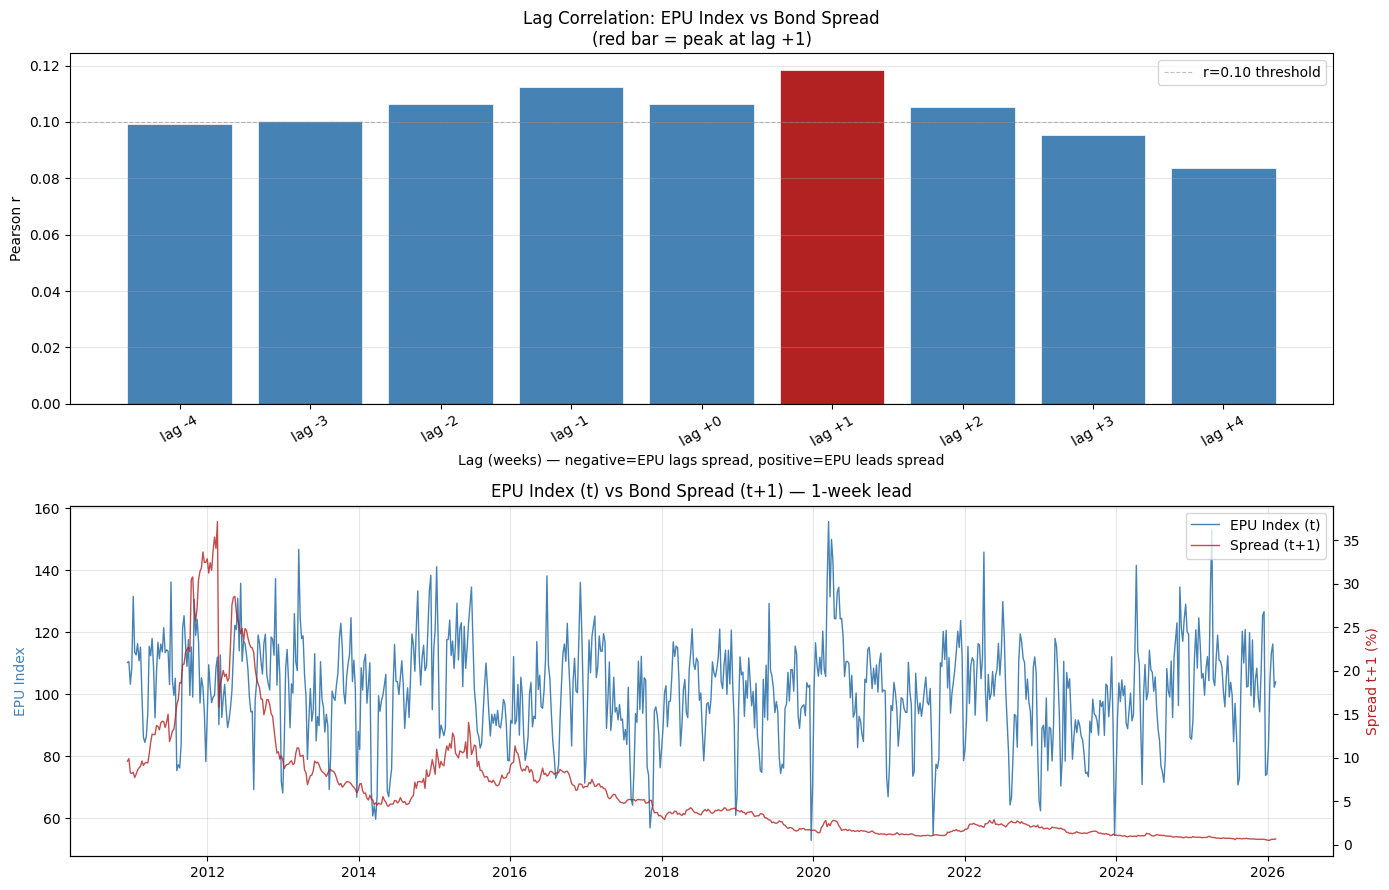


Granger Causality Test: EPU → Spread (lags 1-4)
  lag=1  F-test p-value: 0.2418  
  lag=2  F-test p-value: 0.3196  
  lag=3  F-test p-value: 0.4875  
  lag=4  F-test p-value: 0.5592  


c:\Users\user\Desktop\nlpproject\projectfolder2\king_lo\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


In [25]:
from statsmodels.tsa.stattools import grangercausalitytests

# Lag +1 correlation plot
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Panel 1 — Lag correlation bar chart
lags    = list(range(-4, 5))
pearsons = [0.0993, 0.1003, 0.1062, 0.1125, 0.1064, 0.1185, 0.1053, 0.0955, 0.0838]
colors  = ["steelblue" if l != 1 else "firebrick" for l in lags]

axes[0].bar(lags, pearsons, color=colors, edgecolor="white", linewidth=0.5)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].axhline(0.10, color="gray", linewidth=0.8, linestyle="--", alpha=0.5, label="r=0.10 threshold")
axes[0].set_xlabel("Lag (weeks) — negative=EPU lags spread, positive=EPU leads spread")
axes[0].set_ylabel("Pearson r")
axes[0].set_title("Lag Correlation: EPU Index vs Bond Spread\n(red bar = peak at lag +1)")
axes[0].set_xticks(lags)
axes[0].set_xticklabels([f"lag {l:+d}" for l in lags], rotation=30)
axes[0].legend()
axes[0].grid(alpha=0.3, axis="y")

# Panel 2 — EPU(t) vs Spread(t+1)
epu_lead   = merged_v4["epu_index_v4"].values[:-1]
spread_lag = merged_v4["Spread"].values[1:]
dates_lead = merged_v4["week_dt"].values[:-1]

ax2  = axes[1]
ax2b = ax2.twinx()
ax2.plot(dates_lead,  epu_lead,   color="steelblue", linewidth=1,   label="EPU Index (t)")
ax2b.plot(dates_lead, spread_lag, color="firebrick",  linewidth=1,   label="Spread (t+1)", alpha=0.8)
ax2.set_ylabel("EPU Index", color="steelblue")
ax2b.set_ylabel("Spread t+1 (%)", color="firebrick")
ax2.set_title("EPU Index (t) vs Bond Spread (t+1) — 1-week lead")
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc="upper right")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("epu_lag_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

# Granger causality test
print("\nGranger Causality Test: EPU → Spread (lags 1-4)")
print("=" * 50)
granger_data = pd.DataFrame({
    "spread": detrend(merged_v4["Spread"].values),
    "epu":    detrend(merged_v4["epu_index_v4"].values)
})
results = grangercausalitytests(granger_data[["spread", "epu"]], maxlag=4, verbose=False)
for lag, result in results.items():
    p_val = result[0]["ssr_ftest"][1]
    print(f"  lag={lag}  F-test p-value: {p_val:.4f}  {'***' if p_val<0.01 else '**' if p_val<0.05 else '*' if p_val<0.10 else ''}")